## Plots $N=8$

In [1]:
import qutip as qt
import numpy as np
import matplotlib.pyplot as plt
from iminuit import Minuit
from iminuit.cost import LeastSquares  
from core_functions_Trotter import *

In [2]:
I = qt.qeye(2)

def pauli_tensors(pauli, N):
        return [qt.tensor(*(pauli if k==i else I for k in range(N))) for i in range(N)]

def generate_heisenberg_hamiltonians(N, couplings, b, theta_mix):
    sx = pauli_tensors(qt.sigmax(), N)
    sy = pauli_tensors(qt.sigmay(), N)
    sz = pauli_tensors(qt.sigmaz(), N)

    H_0 = 0
    H_int = 0
    H_XY = 0
    H_XZ = 0
    H_YZ = 0

    for i in range(N):
        H_0 += b*(np.sin(2*theta_mix)*sx[i] - np.cos(2*theta_mix)*sz[i])
        for j in range(i+1, N):
            g = couplings[f"g{i+1}_{j+1}"]

            H_int += g*(sx[i]*sx[j] + sy[i]*sy[j] + sz[i]*sz[j])
            H_XY  += 0.5*g*(sx[i]*sx[j] + sy[i]*sy[j])
            H_XZ  += 0.5*g*(sx[i]*sx[j] + sz[i]*sz[j])
            H_YZ  += 0.5*g*(sy[i]*sy[j] + sz[i]*sz[j])

    return H_0, H_int, H_XY, H_XZ, H_YZ


def generate_basis_vector(base_str):
    for c in base_str:
        if c != '0' and c != '1': raise Exception("Input string can only contain 0 and 1")
    
    vct = qt.basis(2,0) if base_str[0] == "0" else qt.basis(2,1)

    for c in base_str[1:]:
        temp = qt.basis(2,0) if c == "0" else qt.basis(2,1)
        vct = qt.tensor(vct, temp)
    
    return vct

In [3]:
N = 8
mu = 1
theta_mixing = 0.195
upsilon = 0.9
b = mu / N # free Hamiltonian 

couplings, _ = fp_couplings(N, upsilon, mu)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N), pauli_tensors(qt.sigmay(), N), pauli_tensors(qt.sigmaz(), N)

H_0, H_int, H_XY, H_XZ, H_YZ = generate_heisenberg_hamiltonians(N, couplings, b, theta_mixing)

psi00001111 = generate_basis_vector("00001111")


In [4]:
dt_list = np.arange(1, 41) / mu

def compute_single_step_error_Heisenberg(times):
    U_heis = [(-1j*H_int*t).expm()*(-1j*H_0*t).expm() for t in times]
    U_T1 = [(-1j*(H_YZ)*t).expm()*(-1j*(H_XZ)*t).expm()*(-1j*(H_XY)*t).expm()*(-1j*H_0*t).expm() for t in times]
    U_T2 = [(-1j*(H_XY)*(t/2)).expm()*(-1j*(H_XZ)*(t/2)).expm()*(-1j*(H_YZ)*t).expm()*(-1j*(H_XZ)*(t/2)).expm()*(-1j*(H_XY)*(t/2)).expm()*(-1j*H_0*t).expm() for t in times]
    add_err_values1 = [np.max(np.linalg.svd((U_heis[i] - U_T1[i]).full(), compute_uv=False)) for i in range(len(times))]
    add_err_values2 = [np.max(np.linalg.svd((U_heis[i] - U_T2[i]).full(), compute_uv=False)) for i in range(len(times))]
    return U_heis, U_T1, add_err_values1, add_err_values2

_, _, add_T1_vals, add_T2_vals = compute_single_step_error_Heisenberg(dt_list)

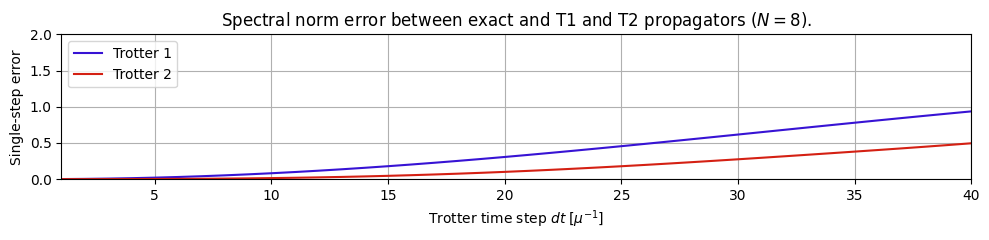

In [6]:
fig, ax=plt.subplots(figsize=(10,2.5))

ax.plot(dt_list, add_T1_vals, color="#3713d4", label="Trotter 1")
ax.plot(dt_list, add_T2_vals, color="#d42013", label="Trotter 2")
ax.set_title(r"Spectral norm error between exact and T1 and T2 propagators ($N=8$).")
ax.set_xlabel(r"Trotter time step $dt\;\left[\mu^{-1}\right]$")
ax.set_ylabel(r"Single-step error")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend(loc=2)
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(0, 2)

plt.grid()
plt.tight_layout()
fig.savefig(r"C:\Users\edori\Desktop\Nexus\Università\Current\MasterThesis\Images\N8plots\propagator_error_compare_N8.pdf", dpi=300)
plt.show()

In [4]:
dt_list = np.arange(1,41) / mu

expect_Z0_0 = qt.expect(sz[0], psi00001111)
expect_Z1_0 = qt.expect(sz[1], psi00001111)
expect_Z2_0 = qt.expect(sz[2], psi00001111)
expect_Z3_0 = qt.expect(sz[3], psi00001111)
expect_Z4_0 = qt.expect(sz[4], psi00001111)
expect_Z5_0 = qt.expect(sz[5], psi00001111)
expect_Z6_0 = qt.expect(sz[6], psi00001111)
expect_Z7_0 = qt.expect(sz[7], psi00001111)

invprob_dt_exact_0 = []
invprob_dt_Trot2_0 = []
invprob_dt_exact_1 = []
invprob_dt_Trot2_1 = []
invprob_dt_exact_2 = []
invprob_dt_Trot2_2 = []
invprob_dt_exact_3 = []
invprob_dt_Trot2_3 = []
invprob_dt_exact_4 = []
invprob_dt_Trot2_4 = []
invprob_dt_exact_5 = []
invprob_dt_Trot2_5 = []
invprob_dt_exact_6 = []
invprob_dt_Trot2_6 = []
invprob_dt_exact_7 = []
invprob_dt_Trot2_7 = []

for dt in dt_list:
    U_free = (-1j*H_0*dt).expm()
    U_exact_dt = (-1j*H_int*dt).expm() * U_free
    U_Trot2_dt = (-1j*(H_XY)*(dt/2)).expm()*(-1j*(H_XZ)*(dt/2)).expm()*(-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*(dt/2)).expm()*(-1j*(H_XY)*(dt/2)).expm()*U_free

    psi_exact_evol = U_exact_dt*psi00001111
    psi_Trot2_evol = U_Trot2_dt*psi00001111

    invprob_dt_exact_0.append(abs(expect_Z0_0-qt.expect(sz[0], psi_exact_evol))/2)
    invprob_dt_Trot2_0.append(abs(expect_Z0_0-qt.expect(sz[0], psi_Trot2_evol))/2)
    invprob_dt_exact_1.append(abs(expect_Z1_0-qt.expect(sz[1], psi_exact_evol))/2)
    invprob_dt_Trot2_1.append(abs(expect_Z1_0-qt.expect(sz[1], psi_Trot2_evol))/2)
    invprob_dt_exact_2.append(abs(expect_Z2_0-qt.expect(sz[2], psi_exact_evol))/2)
    invprob_dt_Trot2_2.append(abs(expect_Z2_0-qt.expect(sz[2], psi_Trot2_evol))/2)
    invprob_dt_exact_3.append(abs(expect_Z3_0-qt.expect(sz[3], psi_exact_evol))/2)
    invprob_dt_Trot2_3.append(abs(expect_Z3_0-qt.expect(sz[3], psi_Trot2_evol))/2)
    invprob_dt_exact_4.append(abs(expect_Z4_0-qt.expect(sz[4], psi_exact_evol))/2)
    invprob_dt_Trot2_4.append(abs(expect_Z4_0-qt.expect(sz[4], psi_Trot2_evol))/2)
    invprob_dt_exact_5.append(abs(expect_Z5_0-qt.expect(sz[5], psi_exact_evol))/2)
    invprob_dt_Trot2_5.append(abs(expect_Z5_0-qt.expect(sz[5], psi_Trot2_evol))/2)
    invprob_dt_exact_6.append(abs(expect_Z6_0-qt.expect(sz[6], psi_exact_evol))/2)
    invprob_dt_Trot2_6.append(abs(expect_Z6_0-qt.expect(sz[6], psi_Trot2_evol))/2)
    invprob_dt_exact_7.append(abs(expect_Z7_0-qt.expect(sz[7], psi_exact_evol))/2)
    invprob_dt_Trot2_7.append(abs(expect_Z7_0-qt.expect(sz[7], psi_Trot2_evol))/2)

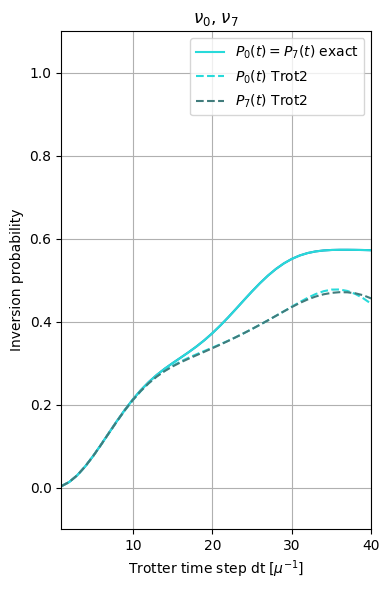

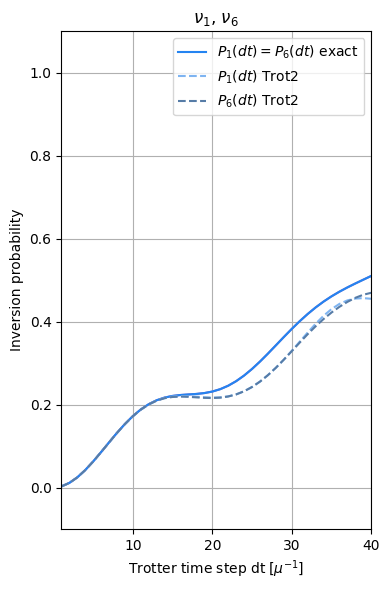

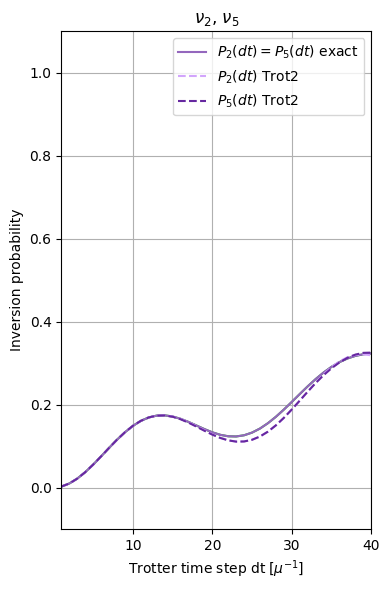

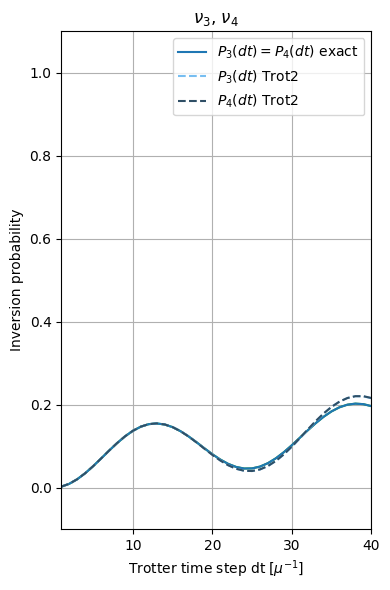

In [5]:
# ----------------
# --- Plotting --- 
# ----------------

show_Trotter = True

# ----- Plot inversion probabilities nu0, nu7 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_0, color="#1f77b4")
ax.plot(dt_list, invprob_dt_exact_7, color="#28dada", label=r"$P_0(t)=P_7(t)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot2_0, color="#28dada", linestyle="--", label=r"$P_0(t)$ Trot2")
    ax.plot(dt_list, invprob_dt_Trot2_7, color="#417c7c", linestyle="--", label=r"$P_7(t)$ Trot2")

ax.set_title(r"$\nu_0$, $\nu_7$")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

# ----- Plot inversion probabilities nu1, nu6 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_1, color="#9467bd")
ax.plot(dt_list, invprob_dt_exact_6, color="#2484f1", label=r"$P_1(dt)=P_6(dt)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot2_1, color="#7eb4f1", linestyle="--", label=r"$P_1(dt)$ Trot2")
    ax.plot(dt_list, invprob_dt_Trot2_6, color="#567ca7", linestyle="--", label=r"$P_6(dt)$ Trot2")

ax.set_title(r"$\nu_1$, $\nu_6$")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

# ----- Plot inversion probabilities nu2, nu5 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_2, color="#2ca02c")
ax.plot(dt_list, invprob_dt_exact_5, color="#9467bd", label=r"$P_2(dt)=P_5(dt)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot2_2, color="#d2a5fc", linestyle="--", label=r"$P_2(dt)$ Trot2")
    ax.plot(dt_list, invprob_dt_Trot2_5, color="#6628a0", linestyle="--", label=r"$P_5(dt)$ Trot2")

ax.set_title(r"$\nu_2$, $\nu_5$")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

# ----- Plot inversion probabilities nu3, nu4 -----

fig, ax=plt.subplots(figsize=(4,6))

ax.plot(dt_list, invprob_dt_exact_3, color="#2ca02c")
ax.plot(dt_list, invprob_dt_exact_4, color="#1f77b4", label=r"$P_3(dt)=P_4(dt)$ exact")

if show_Trotter:
    ax.plot(dt_list, invprob_dt_Trot2_3, color="#77bef1", linestyle="--", label=r"$P_3(dt)$ Trot2")
    ax.plot(dt_list, invprob_dt_Trot2_4, color="#2f4f66", linestyle="--", label=r"$P_4(dt)$ Trot2")

ax.set_title(r"$\nu_3$, $\nu_4$")
ax.set_xlabel(r"Trotter time step $\text{dt}\; \left[\mu^{-1}\right]$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(dt_list), np.max(dt_list))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
plt.show()

In [44]:
T_total = 2001

dt_exact = 1 / mu
dt_1 = 14 / mu
dt_2 = dt_1

r_exact = int(T_total / dt_exact)
r_Trot1 = int(T_total / dt_1)
r_Trot2 = int(T_total / dt_2)

U_free_dt_exact = (-1j*H_0*dt_exact).expm()
U_exact_dt_exact = (-1j*H_int*dt_exact).expm() * U_free_dt_exact

U_free_dt1 = (-1j*H_0*dt_1).expm()
U_free_dt2 = (-1j*H_0*dt_2).expm()
U_Trot1_dt = (-1j*(H_YZ)*dt_1).expm()*(-1j*(H_XZ)*dt_1).expm()*(-1j*(H_XY)*dt_1).expm() * U_free_dt1
U_Trot2_dt = (-1j*(H_XY)*(dt_2/2)).expm()*(-1j*(H_XZ)*(dt_2/2)).expm()*(-1j*(H_YZ)*dt_2).expm()*(-1j*(H_XZ)*(dt_2/2)).expm()*(-1j*(H_XY)*(dt_2/2)).expm()*U_free_dt2

psi_exact = []
psi_Trot1 = []
psi_Trot2 = []

psi_exact.append(psi00001111)
psi_Trot1.append(psi00001111)
psi_Trot2.append(psi00001111)

for i in range(1, r_exact+1): psi_exact.append(U_exact_dt_exact*psi_exact[i-1])
for i in range(1, r_Trot1+1): psi_Trot1.append(U_Trot1_dt*psi_Trot1[i-1])
for i in range(1, r_Trot2+1): psi_Trot2.append(U_Trot2_dt*psi_Trot2[i-1])

tlist_exact = [dt_exact*k for k in range(0, r_exact+1)]
tlist_Trot1 = [dt_1*k for k in range(0, r_Trot1+1)]
tlist_Trot2 = [dt_2*k for k in range(0, r_Trot2+1)]

# exact_Z1_expvl = [qt.expect(sz[1], state) for state in psi_exact]
# Trot1_Z1_expvl = [qt.expect(sz[1], state) for state in psi_Trot1]

exact_Z3_expvl = [qt.expect(sz[3], state) for state in psi_exact]
Trot1_Z3_expvl = [qt.expect(sz[3], state) for state in psi_Trot1]
Trot2_Z3_expvl = [qt.expect(sz[3], state) for state in psi_Trot2]

# invprob_1_exact = [abs(exact_Z1_expvl[0]-exact_Z1_expvl[i])/2 for i in range(0, len(exact_Z1_expvl))]
# invprob_1_Trot1 = [abs(Trot1_Z1_expvl[0]-Trot1_Z1_expvl[i])/2 for i in range(0, len(Trot1_Z1_expvl))]

invprob_3_exact = [abs(exact_Z3_expvl[0]-exact_Z3_expvl[i])/2 for i in range(0, len(exact_Z3_expvl))]
invprob_3_Trot1 = [abs(Trot1_Z3_expvl[0]-Trot1_Z3_expvl[i])/2 for i in range(0, len(Trot1_Z3_expvl))]
invprob_3_Trot2 = [abs(Trot2_Z3_expvl[0]-Trot2_Z3_expvl[i])/2 for i in range(0, len(Trot2_Z3_expvl))]

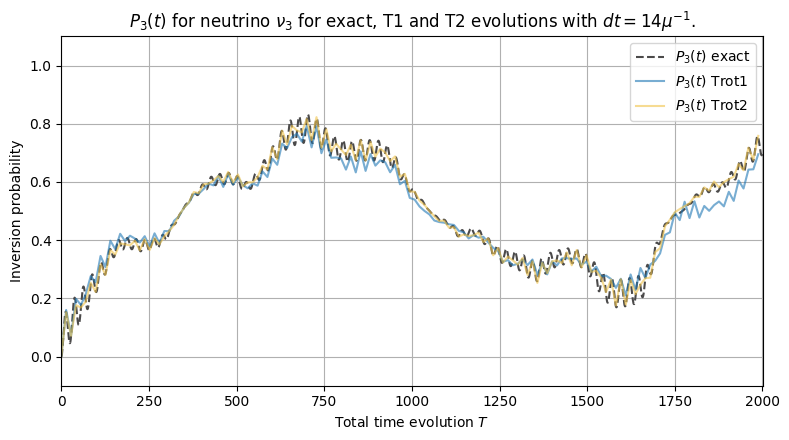

In [48]:

# ----- Plot inversion probabilities -----

fig, ax=plt.subplots(figsize=(16/2,9/2))

ax.plot(tlist_exact, invprob_3_exact, color="#4B4A4A", linestyle="--", label=r"$P_3(t)$ exact")
ax.plot(tlist_Trot1, invprob_3_Trot1, color="#1f77b4", alpha=0.6, label=r"$P_3(t)$ Trot1")
ax.plot(tlist_Trot2, invprob_3_Trot2, color="#f0c34a", alpha=0.6, label=r"$P_3(t)$ Trot2")


ax.set_title(r"$P_3(t)$ for neutrino $\nu_3$ for exact, T1 and T2 evolutions with $dt=14\mu^{-1}$.")
ax.set_xlabel(r"Total time evolution $T$")
ax.set_ylabel(r"Inversion probability")
ax.text(0.02, 0.84, rf"", transform=ax.transAxes, fontsize=10, va="center", bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black"))
ax.legend()
ax.set_xlim(np.min(tlist_exact), np.max(tlist_exact))
ax.set_ylim(-0.1, 1.1)

plt.grid()
plt.tight_layout()
fig.savefig(r"C:\Users\edori\Desktop\Nexus\Università\Current\MasterThesis\Images\N8plots\full_time_evol_compareT1T2_N8.pdf", dpi=300)
plt.show()

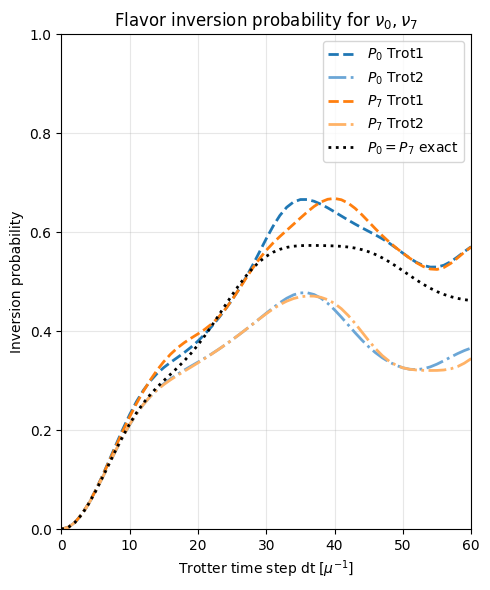

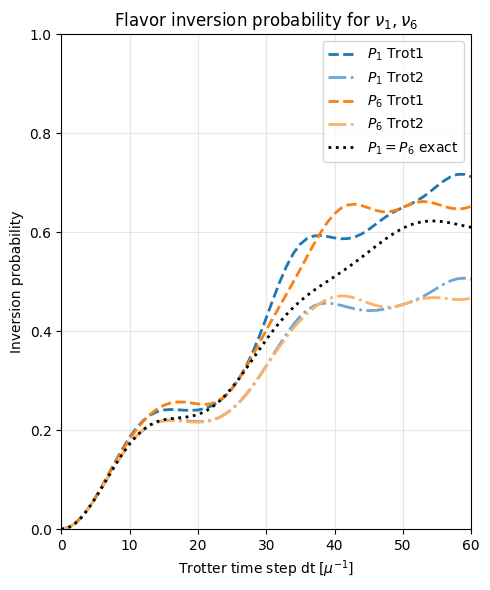

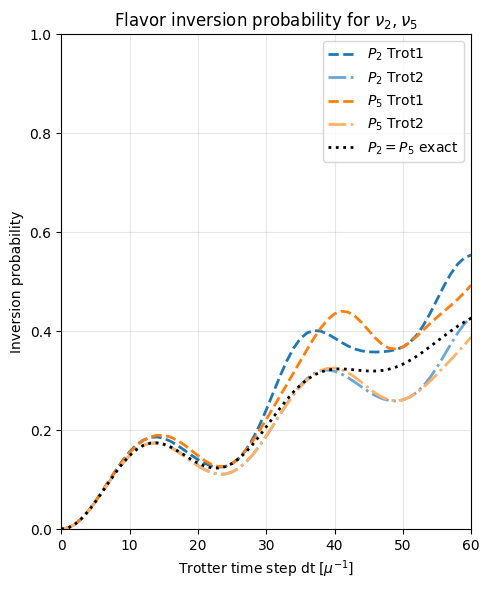

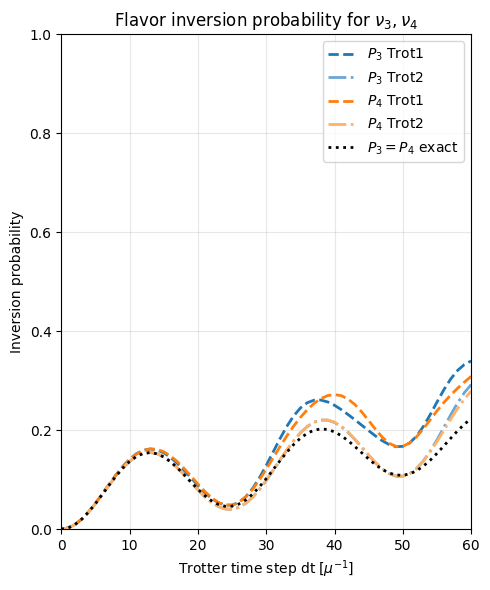

In [ ]:
N = 8
mu = 1
theta_mixing = 0.195
upsilon = 0.9
b = mu / N

couplings, _ = fp_couplings(N, upsilon, mu)

def pauli_tensors(pauli, N):
    return [qt.tensor(*(pauli if i==j else I for j in range(N))) for i in range(N)]

sx, sy, sz = pauli_tensors(qt.sigmax(), N), pauli_tensors(qt.sigmay(), N), pauli_tensors(qt.sigmaz(), N)

H_0, H_int, H_XY, H_XZ, H_YZ = generate_heisenberg_hamiltonians(N, couplings, b, theta_mixing)

dt_list = np.arange(0,61) / mu

psi00001111 = qt.tensor(qt.basis(2,0), qt.basis(2,0), qt.basis(2,0), qt.basis(2,0),
                        qt.basis(2,1), qt.basis(2,1), qt.basis(2,1), qt.basis(2,1))

expect_Z = [qt.expect(sz[i], psi00001111) for i in range(N)]

invprob_dt_exact = [[] for _ in range(N)]
invprob_dt_Trot1 = [[] for _ in range(N)]
invprob_dt_Trot2 = [[] for _ in range(N)]

for dt in dt_list:
    U_free = (-1j*H_0*dt).expm()

    U_exact_dt = (-1j*H_int*dt).expm() * U_free

    U_Trot1_dt = (-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*dt).expm()*(-1j*(H_XY)*dt).expm()*U_free

    U_Trot2_dt = (-1j*(H_XY)*(dt/2)).expm()*(-1j*(H_XZ)*(dt/2)).expm()*(-1j*(H_YZ)*dt).expm()*(-1j*(H_XZ)*(dt/2)).expm()*(-1j*(H_XY)*(dt/2)).expm()*U_free

    for i in range(N):
        invprob_dt_exact[i].append(abs(expect_Z[i]-qt.expect(sz[i], U_exact_dt*psi00001111))/2)
        invprob_dt_Trot1[i].append(abs(expect_Z[i]-qt.expect(sz[i], U_Trot1_dt*psi00001111))/2)
        invprob_dt_Trot2[i].append(abs(expect_Z[i]-qt.expect(sz[i], U_Trot2_dt*psi00001111))/2)


pairs = [(0,7),(1,6),(2,5),(3,4)]

for a,b in pairs:

    fig, ax = plt.subplots(figsize=(5,6))

    cA_t1 = "#1f77b4"
    cA_t2 = "#6ba6d6"
    cB_t1 = "#ff7f0e"
    cB_t2 = "#ffb266"

    ax.plot(dt_list, invprob_dt_Trot1[a], linestyle="--", color=cA_t1, linewidth=2, label=rf"$P_{a}$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot2[a], linestyle="-.", color=cA_t2, linewidth=2, label=rf"$P_{a}$ Trot2")

    ax.plot(dt_list, invprob_dt_Trot1[b], linestyle="--", color=cB_t1, linewidth=2, label=rf"$P_{b}$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot2[b], linestyle="-.", color=cB_t2, linewidth=2, label=rf"$P_{b}$ Trot2")

    ax.plot(dt_list, invprob_dt_exact[a], linestyle=":", color="#000000", linewidth=2, label=rf"$P_{a}=P_{b}$ exact")

    ax.set_xlabel(r"Trotter time step $\mathrm{dt}\;[\mu^{-1}]$")
    ax.set_ylabel(r"Inversion probability")
    ax.set_xlim(np.min(dt_list), np.max(dt_list))
    ax.set_ylim(0,1)
    ax.set_title(rf"Flavor inversion probability for $\nu_{a},\nu_{b}$")
    ax.grid(alpha=0.3)
    ax.legend()

    plt.tight_layout()
    fig.savefig(rf"C:\Users\edori\Desktop\Nexus\Università\Current\MasterThesis\Images\N8plots\singlestep_flvinv_nu{a}nu{b}_N8.pdf", dpi=300)
    plt.show()

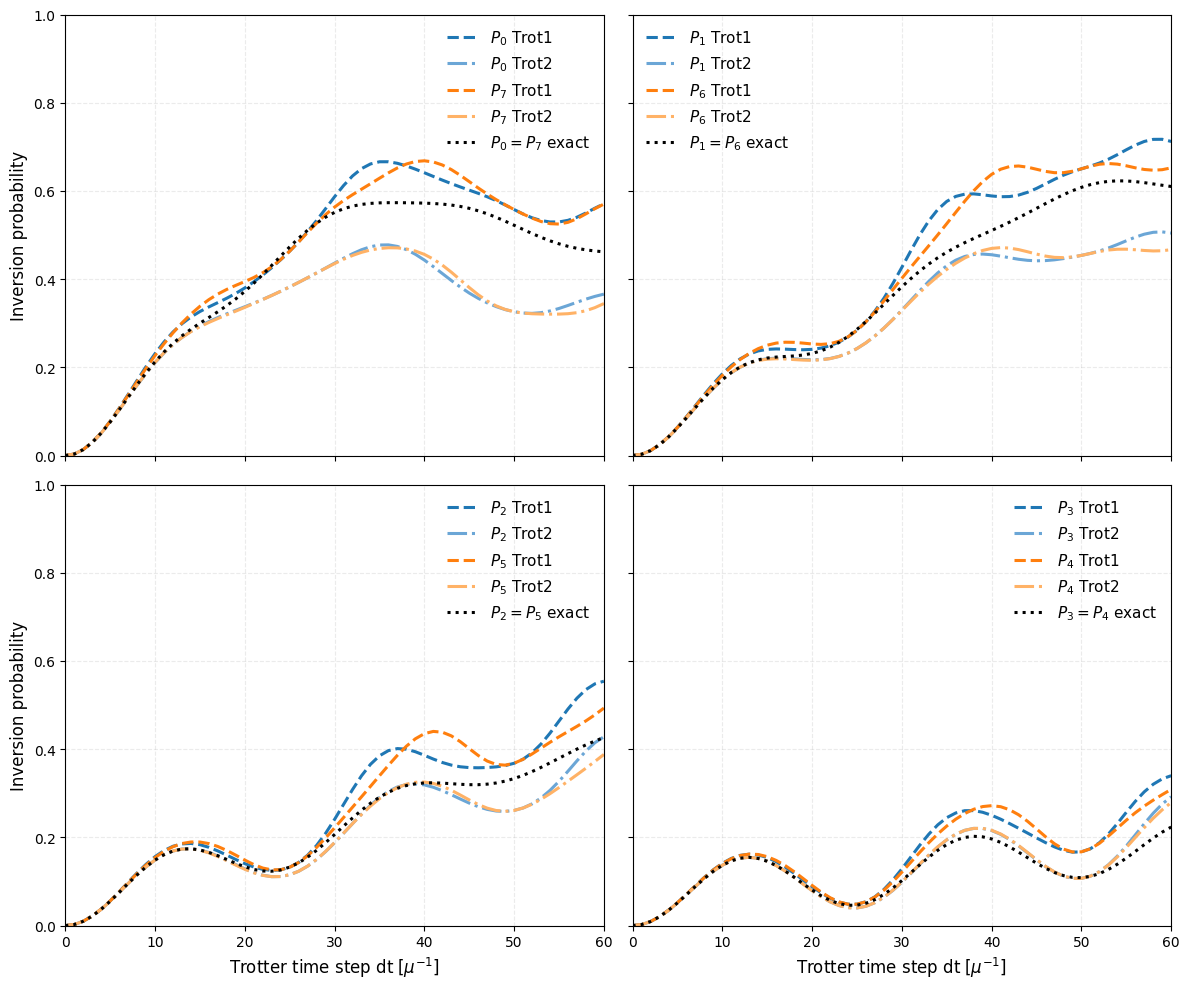

In [52]:
import matplotlib.pyplot as plt

pairs = [(0,7),(1,6),(2,5),(3,4)]

fig, axs = plt.subplots(2, 2, figsize=(12,10), sharex=True, sharey=True)
axs = axs.flatten()

for ax, (a,b) in zip(axs, pairs):

    cA_t1 = "#1f77b4"
    cA_t2 = "#6ba6d6"
    cB_t1 = "#ff7f0e"
    cB_t2 = "#ffb266"

    ax.plot(dt_list, invprob_dt_Trot1[a], linestyle="--", color=cA_t1, linewidth=2.2, label=rf"$P_{a}$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot2[a], linestyle="-.", color=cA_t2, linewidth=2.2, label=rf"$P_{a}$ Trot2")

    ax.plot(dt_list, invprob_dt_Trot1[b], linestyle="--", color=cB_t1, linewidth=2.2, label=rf"$P_{b}$ Trot1")
    ax.plot(dt_list, invprob_dt_Trot2[b], linestyle="-.", color=cB_t2, linewidth=2.2, label=rf"$P_{b}$ Trot2")

    ax.plot(dt_list, invprob_dt_exact[a], linestyle=":", color="#000000", linewidth=2.2, label=rf"$P_{a}=P_{b}$ exact")

    ax.set_xlim(np.min(dt_list), np.max(dt_list))
    ax.set_ylim(0,1)
    ax.grid(alpha=0.25, linestyle="--")

    ax.legend(fontsize=11, frameon=False)

for ax in axs[2:]:
    ax.set_xlabel(r"Trotter time step $\mathrm{dt}\;[\mu^{-1}]$", fontsize=12)

for ax in axs[::2]:
    ax.set_ylabel(r"Inversion probability", fontsize=12)

plt.tight_layout()
fig.savefig(r"C:\Users\edori\Desktop\Nexus\Università\Current\MasterThesis\Images\N8plots\singlestep_flvinv_allpairs_N8_singlelegends.pdf", dpi=300)
plt.show()